In [1]:
!pip install timm thop

# **Import Libraries**

In [2]:
import torch
import torchvision
import timm
import numpy as np
import matplotlib.pyplot as plt

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import confusion_matrix

# **Set Random Seed**

In [3]:
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# **Device (GPU)**

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# **Image Preprocessing**

In [5]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# **Load Dataset**

In [6]:
data_path = "/kaggle/input/datasets/nasimudheen/train-dataset/train_data"

dataset = ImageFolder(data_path, transform=transform)

# **Train / Validation Split**

In [7]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# **DataLoaders**

In [8]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# **Load Pretrained Model**

# **Modify Classification Head**

In [9]:
model = timm.create_model("resnet50", pretrained=True)
model.reset_classifier(30)

# **Move Model to GPU**

In [10]:
model = model.to(device)

# **Loss + Optimizer**

In [11]:
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

# **Training Loop**

In [12]:
epochs = 15

for epoch in range(epochs):

    model.train()

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

    print("Epoch done:", epoch+1)

Epoch done: 1
Epoch done: 2
Epoch done: 3
Epoch done: 4
Epoch done: 5
Epoch done: 6
Epoch done: 7
Epoch done: 8
Epoch done: 9
Epoch done: 10
Epoch done: 11
Epoch done: 12
Epoch done: 13
Epoch done: 14
Epoch done: 15


# **Validation Accuracy**

In [13]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("Validation Accuracy:", correct/total)

Validation Accuracy: 0.9370979270907791


# **4.1 Freeze Backbone (Linear Probe)**

In [14]:
for param in model.parameters():
    param.requires_grad = False

for param in model.get_classifier().parameters():
    param.requires_grad = True

# **Optimizer (only classifier should train)**

In [15]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

# **Training with Accuracy Tracking**

In [16]:
epochs = 15

train_acc_list = []
val_acc_list = []

for epoch in range(epochs):

    model.train()

    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct/total
    train_acc_list.append(train_acc)

    # validation
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct/total
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.3f} Val Acc={val_acc:.3f}")

Epoch 1: Train Acc=0.994 Val Acc=0.936
Epoch 2: Train Acc=0.995 Val Acc=0.945
Epoch 3: Train Acc=0.995 Val Acc=0.929
Epoch 4: Train Acc=0.994 Val Acc=0.936
Epoch 5: Train Acc=0.996 Val Acc=0.938
Epoch 6: Train Acc=0.997 Val Acc=0.939
Epoch 7: Train Acc=0.996 Val Acc=0.939
Epoch 8: Train Acc=0.993 Val Acc=0.939
Epoch 9: Train Acc=0.995 Val Acc=0.939
Epoch 10: Train Acc=0.996 Val Acc=0.938
Epoch 11: Train Acc=0.995 Val Acc=0.932
Epoch 12: Train Acc=0.996 Val Acc=0.936
Epoch 13: Train Acc=0.997 Val Acc=0.941
Epoch 14: Train Acc=0.997 Val Acc=0.935
Epoch 15: Train Acc=0.997 Val Acc=0.933


# **Plot Accuracy vs Epoch (required in report)**

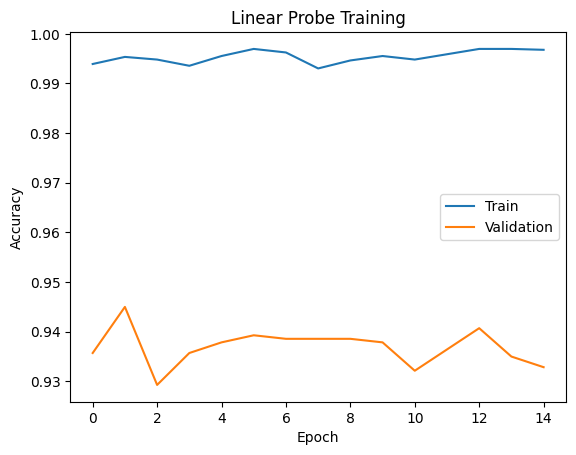

In [17]:
plt.plot(train_acc_list,label="Train")
plt.plot(val_acc_list,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Linear Probe Training")

plt.show()

# **Confusion Matrix**

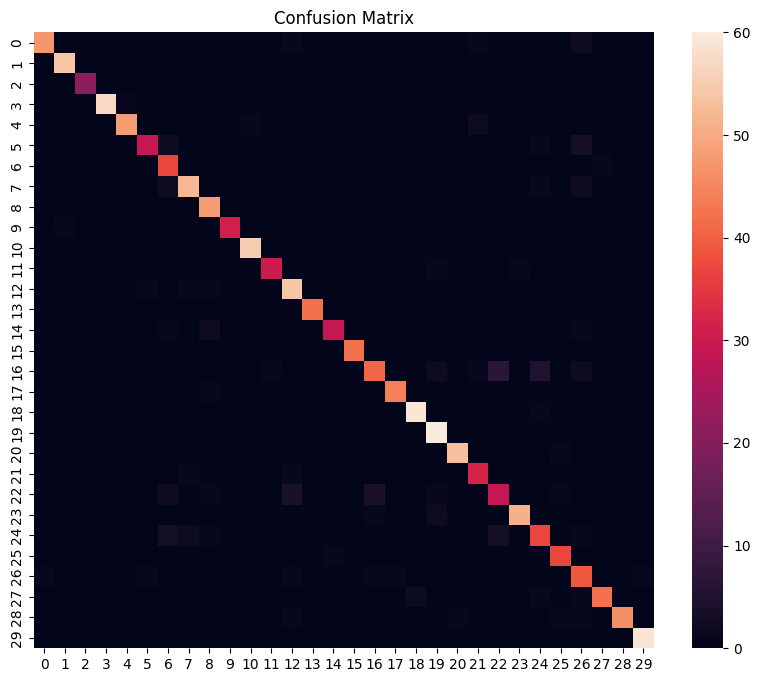

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm)
plt.title("Confusion Matrix")
plt.show()

# **Feature Embedding (PCA Visualization)**

In [19]:
features = []
labels_list = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        feat = model.forward_features(images)

        feat = feat.mean(dim=(2,3))  # global pooling

        features.append(feat.cpu())
        labels_list.append(labels)

features = torch.cat(features)
labels_list = torch.cat(labels_list)

# **PCA**

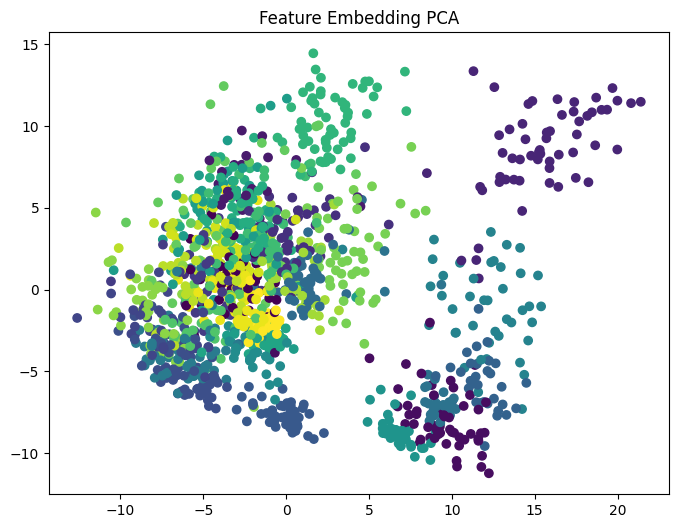

In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

reduced = pca.fit_transform(features)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0],reduced[:,1],c=labels_list)
plt.title("Feature Embedding PCA")
plt.show()

# **4.2 Fine Tuning Strategies**

**Count Trainable Parameters**

In [21]:
def count_trainable_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total

# **Training + Validation Function**

In [22]:
def train_model(model, train_loader, val_loader, epochs=15, lr=1e-4):

    criterion = torch.nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    train_acc_list = []
    val_acc_list = []
    train_loss_list = []

    for epoch in range(epochs):

        model.train()

        correct = 0
        total = 0
        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct/total
        train_loss = running_loss/len(train_loader)

        train_acc_list.append(train_acc)
        train_loss_list.append(train_loss)

        # validation
        model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                preds = outputs.argmax(dim=1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_acc = correct/total
        val_acc_list.append(val_acc)

        print(f"Epoch {epoch+1} | Train Acc {train_acc:.3f} | Val Acc {val_acc:.3f}")

    return train_acc_list, val_acc_list, train_loss_list

# **Strategy 1: Linear Probe**

In [23]:
model = timm.create_model("resnet50", pretrained=True)
model.reset_classifier(30)
model = model.to(device)

# freeze backbone
for param in model.parameters():
    param.requires_grad = False

for param in model.get_classifier().parameters():
    param.requires_grad = True

trainable, total = count_trainable_params(model)
print("Trainable %:", trainable/total)

train_acc_lp, val_acc_lp, loss_lp = train_model(model, train_loader, val_loader)

Trainable %: 0.002608031344913439
Epoch 1 | Train Acc 0.145 | Val Acc 0.310
Epoch 2 | Train Acc 0.399 | Val Acc 0.510
Epoch 3 | Train Acc 0.519 | Val Acc 0.588
Epoch 4 | Train Acc 0.607 | Val Acc 0.618
Epoch 5 | Train Acc 0.631 | Val Acc 0.636
Epoch 6 | Train Acc 0.679 | Val Acc 0.658
Epoch 7 | Train Acc 0.687 | Val Acc 0.663
Epoch 8 | Train Acc 0.712 | Val Acc 0.685
Epoch 9 | Train Acc 0.719 | Val Acc 0.690
Epoch 10 | Train Acc 0.739 | Val Acc 0.706
Epoch 11 | Train Acc 0.743 | Val Acc 0.721
Epoch 12 | Train Acc 0.759 | Val Acc 0.714
Epoch 13 | Train Acc 0.758 | Val Acc 0.718
Epoch 14 | Train Acc 0.765 | Val Acc 0.728
Epoch 15 | Train Acc 0.777 | Val Acc 0.741


# **Strategy 2: Last Block Fine-Tuning**

In [24]:
model = timm.create_model("resnet50", pretrained=True)
model.reset_classifier(30)
model = model.to(device)

# freeze all
for param in model.parameters():
    param.requires_grad = False

# unfreeze last block
for param in model.layer4.parameters():
    param.requires_grad = True

# classifier
for param in model.get_classifier().parameters():
    param.requires_grad = True

trainable, total = count_trainable_params(model)
print("Trainable %:", trainable/total)

train_acc_lb, val_acc_lb, loss_lb = train_model(model, train_loader, val_loader)

Trainable %: 0.6375275133093605
Epoch 1 | Train Acc 0.254 | Val Acc 0.448
Epoch 2 | Train Acc 0.604 | Val Acc 0.706
Epoch 3 | Train Acc 0.757 | Val Acc 0.796
Epoch 4 | Train Acc 0.839 | Val Acc 0.850
Epoch 5 | Train Acc 0.885 | Val Acc 0.874
Epoch 6 | Train Acc 0.916 | Val Acc 0.886
Epoch 7 | Train Acc 0.922 | Val Acc 0.898
Epoch 8 | Train Acc 0.947 | Val Acc 0.905
Epoch 9 | Train Acc 0.951 | Val Acc 0.909
Epoch 10 | Train Acc 0.965 | Val Acc 0.919
Epoch 11 | Train Acc 0.967 | Val Acc 0.913
Epoch 12 | Train Acc 0.976 | Val Acc 0.921
Epoch 13 | Train Acc 0.982 | Val Acc 0.920
Epoch 14 | Train Acc 0.985 | Val Acc 0.914
Epoch 15 | Train Acc 0.986 | Val Acc 0.921


# **Strategy 3: Selective 20% Unfreeze**

In [25]:
model = timm.create_model("resnet50", pretrained=True)
model.reset_classifier(30)
model = model.to(device)

# freeze all
for param in model.parameters():
    param.requires_grad = False

# unfreeze last blocks
for param in model.layer3.parameters():
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True

# classifier
for param in model.get_classifier().parameters():
    param.requires_grad = True

trainable, total = count_trainable_params(model)
print("Trainable %:", trainable/total)

train_acc_sel, val_acc_sel, loss_sel = train_model(model, train_loader, val_loader)

Trainable %: 0.9386950135815343
Epoch 1 | Train Acc 0.265 | Val Acc 0.534
Epoch 2 | Train Acc 0.668 | Val Acc 0.816
Epoch 3 | Train Acc 0.837 | Val Acc 0.889
Epoch 4 | Train Acc 0.901 | Val Acc 0.919
Epoch 5 | Train Acc 0.937 | Val Acc 0.923
Epoch 6 | Train Acc 0.958 | Val Acc 0.929
Epoch 7 | Train Acc 0.968 | Val Acc 0.931
Epoch 8 | Train Acc 0.982 | Val Acc 0.937
Epoch 9 | Train Acc 0.982 | Val Acc 0.944
Epoch 10 | Train Acc 0.987 | Val Acc 0.931
Epoch 11 | Train Acc 0.992 | Val Acc 0.938
Epoch 12 | Train Acc 0.993 | Val Acc 0.942
Epoch 13 | Train Acc 0.994 | Val Acc 0.941
Epoch 14 | Train Acc 0.994 | Val Acc 0.945
Epoch 15 | Train Acc 0.993 | Val Acc 0.942


# **Strategy 4: Full Fine-Tuning**

In [26]:
model = timm.create_model("resnet50", pretrained=True)
model.reset_classifier(30)
model = model.to(device)

# unfreeze everything
for param in model.parameters():
    param.requires_grad = True

trainable, total = count_trainable_params(model)
print("Trainable %:", trainable/total)

train_acc_full, val_acc_full, loss_full = train_model(model, train_loader, val_loader)

Trainable %: 1.0
Epoch 1 | Train Acc 0.267 | Val Acc 0.518
Epoch 2 | Train Acc 0.690 | Val Acc 0.814
Epoch 3 | Train Acc 0.852 | Val Acc 0.892
Epoch 4 | Train Acc 0.912 | Val Acc 0.912
Epoch 5 | Train Acc 0.950 | Val Acc 0.925
Epoch 6 | Train Acc 0.968 | Val Acc 0.930
Epoch 7 | Train Acc 0.979 | Val Acc 0.936
Epoch 8 | Train Acc 0.986 | Val Acc 0.944
Epoch 9 | Train Acc 0.991 | Val Acc 0.941
Epoch 10 | Train Acc 0.990 | Val Acc 0.945
Epoch 11 | Train Acc 0.993 | Val Acc 0.944
Epoch 12 | Train Acc 0.993 | Val Acc 0.947
Epoch 13 | Train Acc 0.994 | Val Acc 0.941
Epoch 14 | Train Acc 0.997 | Val Acc 0.946
Epoch 15 | Train Acc 0.995 | Val Acc 0.944


# **Plot Accuracy vs Fine-Tuning Strategy**

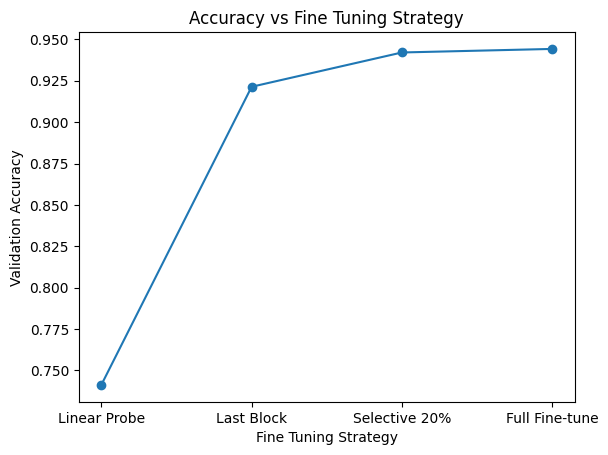

In [27]:
results = [
    val_acc_lp[-1],
    val_acc_lb[-1],
    val_acc_sel[-1],
    val_acc_full[-1]
]

labels = [
    "Linear Probe",
    "Last Block",
    "Selective 20%",
    "Full Fine-tune"
]

plt.plot(labels, results, marker="o")

plt.xlabel("Fine Tuning Strategy")
plt.ylabel("Validation Accuracy")
plt.title("Accuracy vs Fine Tuning Strategy")

plt.show()

# **Plot Training Loss (Convergence)**

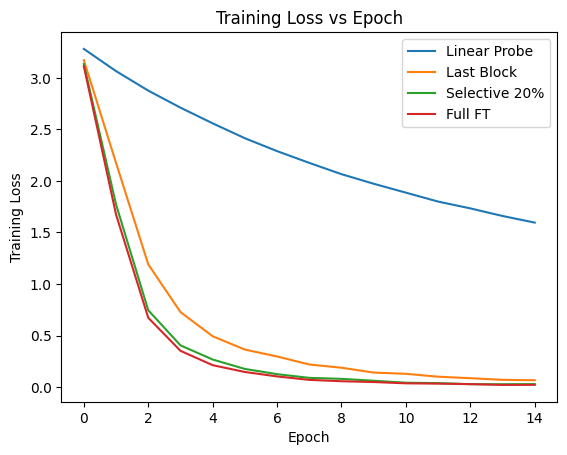

In [28]:
plt.plot(loss_lp,label="Linear Probe")
plt.plot(loss_lb,label="Last Block")
plt.plot(loss_sel,label="Selective 20%")
plt.plot(loss_full,label="Full FT")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()

plt.title("Training Loss vs Epoch")

plt.show()

# **4.3 Create Dataset Subsets (100%, 20%, 5%)**

In [29]:
import torch
from torch.utils.data import random_split

total_size = len(dataset)

size_100 = total_size
size_20 = int(0.2 * total_size)
size_5 = int(0.05 * total_size)

dataset_100, _ = random_split(dataset, [size_100, 0])
dataset_20, _ = random_split(dataset, [size_20, total_size - size_20])
dataset_5, _ = random_split(dataset, [size_5, total_size - size_5])

print(len(dataset_100), len(dataset_20), len(dataset_5))

6993 1398 349


# **DataLoaders**

In [30]:
from torch.utils.data import DataLoader

train_loader_100 = DataLoader(dataset_100, batch_size=32, shuffle=True)
train_loader_20 = DataLoader(dataset_20, batch_size=32, shuffle=True)
train_loader_5 = DataLoader(dataset_5, batch_size=32, shuffle=True)

val_loader_fs = val_loader

# **Train with 100% Data**

In [31]:
model = timm.create_model("resnet50", pretrained=True)
model.reset_classifier(30)
model = model.to(device)

train_acc_100, val_acc_100, loss_100 = train_model(
    model,
    train_loader_100,
    val_loader_fs,
    epochs=15
)

acc100 = val_acc_100[-1]
print("Validation Acc (100% data):", acc100)

Epoch 1 | Train Acc 0.328 | Val Acc 0.704
Epoch 2 | Train Acc 0.761 | Val Acc 0.898
Epoch 3 | Train Acc 0.885 | Val Acc 0.961
Epoch 4 | Train Acc 0.931 | Val Acc 0.979
Epoch 5 | Train Acc 0.957 | Val Acc 0.985
Epoch 6 | Train Acc 0.972 | Val Acc 0.985
Epoch 7 | Train Acc 0.979 | Val Acc 0.994
Epoch 8 | Train Acc 0.984 | Val Acc 0.986
Epoch 9 | Train Acc 0.990 | Val Acc 0.999
Epoch 10 | Train Acc 0.992 | Val Acc 0.998
Epoch 11 | Train Acc 0.993 | Val Acc 0.999
Epoch 12 | Train Acc 0.995 | Val Acc 1.000
Epoch 13 | Train Acc 0.996 | Val Acc 0.999
Epoch 14 | Train Acc 0.996 | Val Acc 0.999
Epoch 15 | Train Acc 0.996 | Val Acc 0.999
Validation Acc (100% data): 0.9992852037169406


In [42]:
torch.save(model.state_dict(),'resnet50_100percent.pth')

# **Train with 20% Data**

In [32]:
model = timm.create_model("resnet50", pretrained=True)
model.reset_classifier(30)
model = model.to(device)

train_acc_20, val_acc_20, loss_20 = train_model(
    model,
    train_loader_20,
    val_loader_fs,
    epochs=15
)

acc20 = val_acc_20[-1]
print("Validation Acc (20% data):", acc20)

Epoch 1 | Train Acc 0.089 | Val Acc 0.195
Epoch 2 | Train Acc 0.280 | Val Acc 0.327
Epoch 3 | Train Acc 0.402 | Val Acc 0.420
Epoch 4 | Train Acc 0.518 | Val Acc 0.514
Epoch 5 | Train Acc 0.607 | Val Acc 0.614
Epoch 6 | Train Acc 0.720 | Val Acc 0.726
Epoch 7 | Train Acc 0.824 | Val Acc 0.793
Epoch 8 | Train Acc 0.884 | Val Acc 0.851
Epoch 9 | Train Acc 0.930 | Val Acc 0.875
Epoch 10 | Train Acc 0.954 | Val Acc 0.886
Epoch 11 | Train Acc 0.969 | Val Acc 0.899
Epoch 12 | Train Acc 0.970 | Val Acc 0.896
Epoch 13 | Train Acc 0.984 | Val Acc 0.911
Epoch 14 | Train Acc 0.986 | Val Acc 0.912
Epoch 15 | Train Acc 0.990 | Val Acc 0.907
Validation Acc (20% data): 0.9070764832022874


# **Train with 5% Data**

In [33]:
model = timm.create_model("resnet50", pretrained=True)
model.reset_classifier(30)
model = model.to(device)

train_acc_5, val_acc_5, loss_5 = train_model(
    model,
    train_loader_5,
    val_loader_fs,
    epochs=15
)

acc5 = val_acc_5[-1]
print("Validation Acc (5% data):", acc5)

Epoch 1 | Train Acc 0.029 | Val Acc 0.054
Epoch 2 | Train Acc 0.117 | Val Acc 0.089
Epoch 3 | Train Acc 0.195 | Val Acc 0.128
Epoch 4 | Train Acc 0.295 | Val Acc 0.158
Epoch 5 | Train Acc 0.327 | Val Acc 0.171
Epoch 6 | Train Acc 0.318 | Val Acc 0.166
Epoch 7 | Train Acc 0.332 | Val Acc 0.196
Epoch 8 | Train Acc 0.367 | Val Acc 0.215
Epoch 9 | Train Acc 0.390 | Val Acc 0.230
Epoch 10 | Train Acc 0.424 | Val Acc 0.238
Epoch 11 | Train Acc 0.458 | Val Acc 0.265
Epoch 12 | Train Acc 0.487 | Val Acc 0.281
Epoch 13 | Train Acc 0.513 | Val Acc 0.297
Epoch 14 | Train Acc 0.590 | Val Acc 0.316
Epoch 15 | Train Acc 0.685 | Val Acc 0.329
Validation Acc (5% data): 0.3288062902072909


# **Compute Performance Drop**

In [34]:
delta = (acc100 - acc5) / acc100

print("Relative Performance Drop Δ:", delta)

Relative Performance Drop Δ: 0.670958512160229


# **Plot Few-Shot Results**

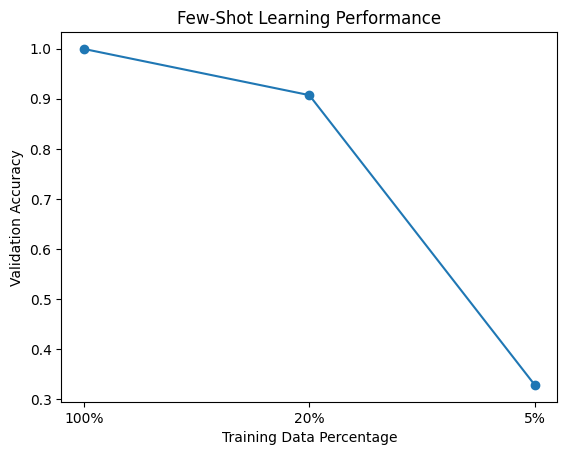

In [35]:
labels = ["100%", "20%", "5%"]
acc_values = [acc100, acc20, acc5]

plt.plot(labels, acc_values, marker="o")

plt.xlabel("Training Data Percentage")
plt.ylabel("Validation Accuracy")
plt.title("Few-Shot Learning Performance")

plt.show()

# **Training vs Validation Gap (Overfitting Check)**

In [36]:
gap_100 = train_acc_100[-1] - val_acc_100[-1]
gap_20 = train_acc_20[-1] - val_acc_20[-1]
gap_5 = train_acc_5[-1] - val_acc_5[-1]

print("Gap 100%:", gap_100)
print("Gap 20%:", gap_20)
print("Gap 5%:", gap_5)

Gap 100%: -0.0030032074349443105
Gap 20%: 0.08290921064606738
Gap 5%: 0.35600746337437095


# **4.4 Gaussian Noise Function**

In [37]:
import torch

def add_gaussian_noise(images, sigma):

    noise = torch.randn_like(images) * sigma
    noisy_images = images + noise

    noisy_images = torch.clamp(noisy_images, 0, 1)

    return noisy_images

# **Brightness Shift Function**

In [38]:
def brightness_shift(images, factor=1.5):

    bright_images = images * factor

    bright_images = torch.clamp(bright_images, 0, 1)

    return bright_images

# **Motion Blur Transform**

In [39]:
import torchvision.transforms as transforms

motion_blur = transforms.GaussianBlur(kernel_size=9)

In [43]:
model = timm.create_model("resnet50", pretrained=False)
model.reset_classifier(30)

model.load_state_dict(torch.load("resnet50_100percent.pth"))

model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     

# **Evaluation Function with Corruption**

In [45]:
def evaluate_corruption(model, val_loader, corruption=None, sigma=None):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            if corruption == "gaussian":
                images = add_gaussian_noise(images, sigma)

            elif corruption == "brightness":
                images = brightness_shift(images)

            elif corruption == "motion":
                images = motion_blur(images)

            outputs = model(images)

            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct/total

    return acc

# **Clean Accuracy**

In [46]:
acc_clean = evaluate_corruption(model, val_loader)

print("Clean Accuracy:", acc_clean)

Clean Accuracy: 0.06862044317369549


# **Gaussian Noise Evaluation**

In [48]:
acc_g05 = evaluate_corruption(model, val_loader, "gaussian", 0.05)
acc_g1 = evaluate_corruption(model, val_loader, "gaussian", 0.1)
acc_g2 = evaluate_corruption(model, val_loader, "gaussian", 0.2)

print("Gaussian σ=0.05:", acc_g05)
print("Gaussian σ=0.1:", acc_g1)
print("Gaussian σ=0.2:", acc_g2)

Gaussian σ=0.05: 0.03788420300214439
Gaussian σ=0.1: 0.03859899928520372
Gaussian σ=0.2: 0.03859899928520372


# **Motion Blur**

In [49]:
acc_motion = evaluate_corruption(model, val_loader, "motion")

print("Motion Blur Accuracy:", acc_motion)

Motion Blur Accuracy: 0.05289492494639028


# **Brightness Shift**

In [50]:
acc_bright = evaluate_corruption(model, val_loader, "brightness")

print("Brightness Shift Accuracy:", acc_bright)

Brightness Shift Accuracy: 0.03359542530378842


# **Corruption Error**
Corruption Error = 1 - Acc_corrupted

In [52]:
ce_g05 = 1 - acc_g05
ce_g1 = 1 - acc_g1
ce_g2 = 1 - acc_g2
ce_motion = 1 - acc_motion
ce_bright = 1 - acc_bright

print("Corruption Errors:")
print(ce_g05, ce_g1, ce_g2, ce_motion, ce_bright)

Corruption Errors:
0.9621157969978557 0.9614010007147963 0.9614010007147963 0.9471050750536097 0.9664045746962115


# **Relative Robustness**
Relative Robustness = Acc_corrupted / Acc_clean

In [53]:
rr_g05 = acc_g05 / acc_clean
rr_g1 = acc_g1 / acc_clean
rr_g2 = acc_g2 / acc_clean
rr_motion = acc_motion / acc_clean
rr_bright = acc_bright / acc_clean

print("Relative Robustness:")
print(rr_g05, rr_g1, rr_g2, rr_motion, rr_bright)

Relative Robustness:
0.5520833333333334 0.5625 0.5625 0.7708333333333335 0.4895833333333334


# **4.5 — Layer-Wise Feature Probing**
Select 900 Images (30 classes × 30 samples)

In [54]:
from collections import defaultdict
import torch

samples_per_class = 30
class_counts = defaultdict(int)

indices = []

for idx, (_, label) in enumerate(dataset):

    if class_counts[label] < samples_per_class:
        indices.append(idx)
        class_counts[label] += 1

subset = torch.utils.data.Subset(dataset, indices)

subset_loader = DataLoader(subset, batch_size=32)

print("Total samples:", len(subset))

Total samples: 900


# **Extract Layer Features**

In [55]:
def extract_features(model, loader):

    early_features = []
    mid_features = []
    final_features = []
    labels_list = []

    model.eval()

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            x = model.conv1(images)
            x = model.bn1(x)
            x = model.act1(x)
            x = model.maxpool(x)

            early = torch.flatten(x,1)

            x = model.layer1(x)
            x = model.layer2(x)

            mid = torch.flatten(x,1)

            x = model.layer3(x)
            x = model.layer4(x)

            final = torch.flatten(x,1)

            early_features.append(early.cpu())
            mid_features.append(mid.cpu())
            final_features.append(final.cpu())

            labels_list.append(labels)

    early_features = torch.cat(early_features)
    mid_features = torch.cat(mid_features)
    final_features = torch.cat(final_features)

    labels_list = torch.cat(labels_list)

    return early_features, mid_features, final_features, labels_list

# **Run Feature Extraction**

In [57]:
early_f, mid_f, final_f, labels_f = extract_features(model, subset_loader)

print(early_f.shape, mid_f.shape, final_f.shape)

torch.Size([900, 200704]) torch.Size([900, 401408]) torch.Size([900, 100352])


# **Train Linear Classifier for Each Layer**

In [83]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

def train_probe(features, labels):

    X_train, X_test, y_train, y_test = train_test_split(
        features, labels, test_size=0.3, random_state=42
    )

    clf=LogisticRegression(max_iter=1000)

    clf.fit(X_train, y_train)

    preds = clf.predict(X_test)

    acc = accuracy_score(y_test, preds)

    return acc

In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    early_f.numpy(), labels_f.numpy(), test_size=0.3, random_state=42
)
clf=LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

preds = clf.predict(X_test)

# **Compute Layer Accuracies**

In [93]:
acc_early = train_probe(early_f.numpy(), labels_f.numpy())
acc_mid = train_probe(mid_f.numpy(), labels_f.numpy())
acc_final = train_probe(final_f.numpy(), labels_f.numpy())

print("Early Layer Acc:", acc_early)
print("Mid Layer Acc:", acc_mid)
print("Final Layer Acc:", acc_final)

Early Layer Acc: 0.4
Mid Layer Acc: 0.4185185185185185
Final Layer Acc: 0.37037037037037035


# **Plot Accuracy vs Layer Depth**

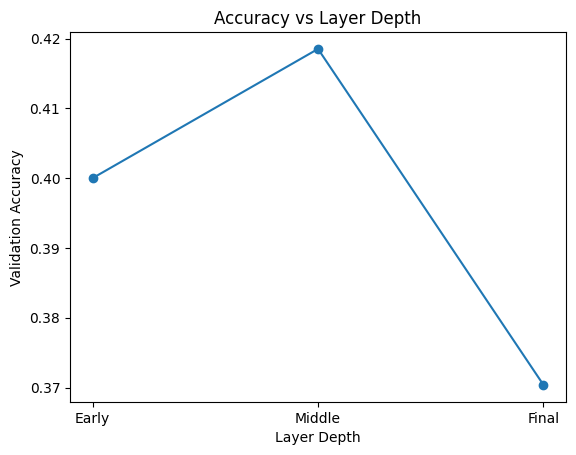

In [95]:
layers = ["Early", "Middle", "Final"]
acc_values = [acc_early, acc_mid, acc_final]

plt.plot(layers, acc_values, marker="o")

plt.xlabel("Layer Depth")
plt.ylabel("Validation Accuracy")

plt.title("Accuracy vs Layer Depth")

plt.show()

# **Feature Norm Statistics**

In [88]:
import numpy as np

norm_early = np.linalg.norm(early_f.numpy(), axis=1)
norm_mid = np.linalg.norm(mid_f.numpy(), axis=1)
norm_final = np.linalg.norm(final_f.numpy(), axis=1)

print("Early norm mean:", norm_early.mean())
print("Mid norm mean:", norm_mid.mean())
print("Final norm mean:", norm_final.mean())

Early norm mean: 118.76243
Mid norm mean: 62.47081
Final norm mean: 15.319289


# **PCA Visualization**

In [89]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

early_2d = pca.fit_transform(early_f)
mid_2d = pca.fit_transform(mid_f)
final_2d = pca.fit_transform(final_f)

# **Plot PCA for Final Layer**

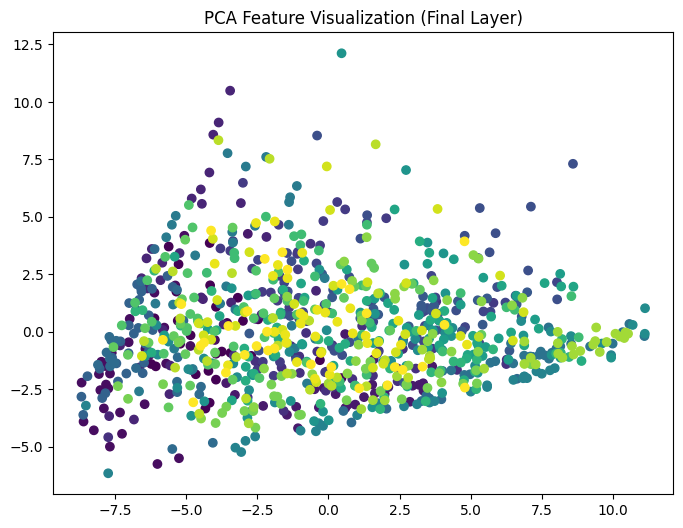

In [90]:
plt.figure(figsize=(8,6))

plt.scatter(final_2d[:,0], final_2d[:,1], c=labels_f)

plt.title("PCA Feature Visualization (Final Layer)")

plt.show()